In [ ]:
import json
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer

# Конфигурация — меняй здесь
MODEL_NAME = "Qwen/Qwen2.5-Coder-1.5B-Instruct"
TRAIN_FILE = "/home/danil-pc/fine-tuning_project/data/final/train.jsonl"
VAL_FILE = "/home/danil-pc/fine-tuning_project/data/final/val.jsonl"

# Настройки графиков — стиль под тёмный/светлый фон ноутбука
plt.rcParams.update(
    {
        "figure.facecolor": "none",  # прозрачный фон фигуры
        "axes.facecolor": "#f8f8f8",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.4,
        "grid.linestyle": "--",
        "font.size": 11,
    }
)

print("Импорты загружены")

/home/danil-pc/fine-tuning_project/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Импорты загружены


In [ ]:
print(f"Загружаем токенайзер: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Токенайзер загружен. Размер словаря: {tokenizer.vocab_size:,}")

Загружаем токенайзер: Qwen/Qwen2.5-Coder-1.5B-Instruct
✅ Токенайзер загружен. Размер словаря: 151,643


In [ ]:
def format_sample(sample: dict) -> str:
    """
    Применяет chat template к одному примеру.

    Почему важно делать именно так, а не просто считать len(text):
    Chat template добавляет специальные токены-маркеры
    (<|im_start|>, <|im_end|>, роли "system"/"user"/"assistant"),
    которые тоже занимают место в последовательности.
    Считать длину без шаблона — значит недооценить реальную длину.
    """
    return tokenizer.apply_chat_template(
        sample["messages"],
        tokenize=False,  # Возвращаем строку, не тензор
        add_generation_prompt=False,  # Не добавляем токен начала ответа
    )


def load_and_tokenize(filepath: str) -> tuple[list[int], dict[str, list[int]]]:
    """
    Читает jsonl-файл, форматирует каждый пример через chat template
    и возвращает список длин токенов + разбивку по источнику данных.
    """
    lengths = []
    by_source = defaultdict(list)

    with open(filepath, encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        sample = json.loads(line.strip())
        formatted = format_sample(sample)

        # encode() без add_special_tokens=True: они уже добавлены chat template
        n_tokens = len(tokenizer.encode(formatted, add_special_tokens=False))
        lengths.append(n_tokens)

        source = sample.get("source", "unknown")
        by_source[source].append(n_tokens)

    return lengths, dict(by_source)


def round_up_power2(n: int) -> int:
    """Округляет до ближайшей степени двойки: 300 → 512, 900 → 1024."""
    p = 1
    while p < n:
        p *= 2
    return p


def estimate_vram_mb(seq_len: int, batch: int) -> float:
    """
    Оценивает потребление VRAM при QLoRA-обучении.
    Параметры архитектуры Qwen2.5-1.5B: 28 слоёв, hidden=1536, 2 KV-головы.
    """
    n_layers, n_kv_heads, head_dim, hidden = 28, 2, 64, 1536

    # Байт на один токен для KV-cache (bfloat16 = 2 байта)
    kv_per_token_bytes = 2 * n_layers * n_kv_heads * head_dim * 2
    kv_mb = (kv_per_token_bytes * seq_len * batch) / (1024**2)

    # Активации при gradient checkpointing (~1/4 от полного хранения)
    act_mb = (hidden * seq_len * batch * 2) / (1024**2) / 4

    model_mb = 1090  # Веса модели в NF4
    lora_mb = 80  # LoRA-адаптеры r=16 в BF16
    optim_mb = 40  # paged_adamw_8bit (только для LoRA-параметров)
    cuda_mb = 300  # CUDA context + PyTorch allocator overhead

    return model_mb + lora_mb + optim_mb + cuda_mb + kv_mb + act_mb


print("Функции готовы")

✅ Функции готовы


In [ ]:
print("Токенизируем train...")
train_lens, train_by_source = load_and_tokenize(TRAIN_FILE)

print("Токенизируем val...")
val_lens, val_by_source = load_and_tokenize(VAL_FILE)

train_arr = np.array(train_lens)
val_arr = np.array(val_lens)

print("\n Готово.")
print(f"   Train: {len(train_lens)} примеров")
print(f"   Val:   {len(val_lens)} примеров")
print(f"   Источники в train: {list(train_by_source.keys())}")

Токенизируем train...
Токенизируем val...

✅ Готово.
   Train: 1105 примеров
   Val:   123 примеров
   Источники в train: ['unknown']


In [ ]:
def print_stats(arr: np.ndarray, name: str) -> None:
    p95 = int(np.percentile(arr, 95))
    p99 = int(np.percentile(arr, 99))
    pmax = int(arr.max())

    print(f"\n{'─' * 52}")
    print(f"  {name} ({len(arr)} примеров)")
    print(f"{'─' * 52}")
    print(f"  {'Мин:':15} {arr.min():>6} токенов")
    print(f"  {'Макс:':15} {arr.max():>6} токенов")
    print(f"  {'Среднее:':15} {arr.mean():>9.1f}")
    print(f"  {'Медиана:':15} {np.median(arr):>9.1f}")
    print(f"  {'Стд. откл.:':15} {arr.std():>9.1f}")
    print("\n  Перцентили:")
    for p in [50, 75, 90, 95, 99, 100]:
        val = int(np.percentile(arr, p))
        print(f"    p{p:<3}: {val:>5} токенов")

    print("\n  Рекомендации по max_seq_length:")
    print(f"     p95  → {round_up_power2(p95):>6}  (~5% примеров обрежется)")
    print(f"     p99  → {round_up_power2(p99):>6}  (~1% обрежется)")
    print(f"     p100 → {round_up_power2(pmax):>6}  (ноль потерь)")


print_stats(train_arr, "Train")
print_stats(val_arr, "Val")

# Разбивка по источникам
if len(train_by_source) > 1:
    print(f"\n{'─' * 52}")
    print("  Разбивка по источникам (train)")
    print(f"{'─' * 52}")
    for src, lens in sorted(train_by_source.items()):
        la = np.array(lens)
        print(
            f"  {src:20}: {len(la):4} прим. | "
            f"avg={la.mean():.0f} | "
            f"p95={int(np.percentile(la, 95)):>5} | "
            f"max={la.max()}"
        )


────────────────────────────────────────────────────
  Train (1105 примеров)
────────────────────────────────────────────────────
  Мин:               111 токенов
  Макс:             1056 токенов
  Среднее:            318.0
  Медиана:            327.0
  Стд. откл.:          74.9

  Перцентили:
    p50 :   327 токенов
    p75 :   363 токенов
    p90 :   399 токенов
    p95 :   419 токенов
    p99 :   459 токенов
    p100:  1056 токенов

  💡 Рекомендации по max_seq_length:
     p95  →    512  (~5% примеров обрежется)
     p99  →    512  (~1% обрежется)
     p100 →   2048  (ноль потерь)

────────────────────────────────────────────────────
  Val (123 примеров)
────────────────────────────────────────────────────
  Мин:               120 токенов
  Макс:              469 токенов
  Среднее:            324.9
  Медиана:            335.0
  Стд. откл.:          66.2

  Перцентили:
    p50 :   335 токенов
    p75 :   358 токенов
    p90 :   398 токенов
    p95 :   424 токенов
    p99 :   464 ток

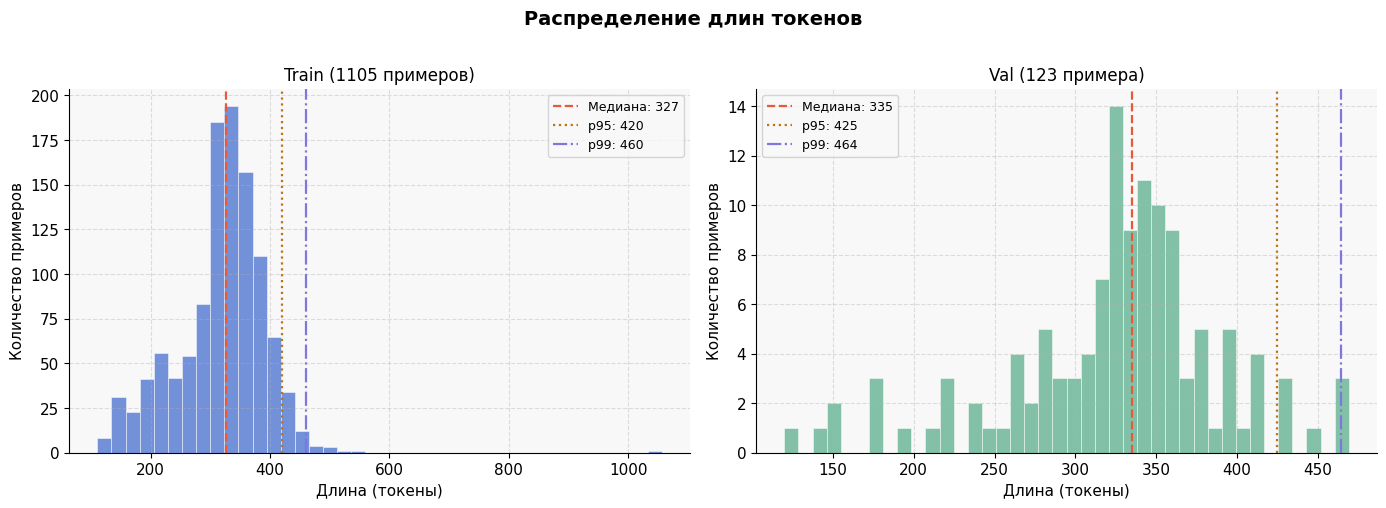

✅ График сохранён: plots/plot1_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Распределение длин токенов", fontsize=14, fontweight="bold", y=1.01
)

COLORS = {"train": "#5B7FD4", "val": "#6DB89A"}

for ax, arr, name, color in zip(
    axes,
    [train_arr, val_arr],
    ["Train (1105 примеров)", "Val (123 примера)"],
    [COLORS["train"], COLORS["val"]],
):
    ax.hist(
        arr, bins=40, color=color, alpha=0.85, edgecolor="white", linewidth=0.4
    )

    # Вертикальные линии: медиана, p95, p99
    median = np.median(arr)
    p95 = np.percentile(arr, 95)
    p99 = np.percentile(arr, 99)

    ax.axvline(
        median,
        color="#E8593C",
        linewidth=1.6,
        linestyle="--",
        label=f"Медиана: {median:.0f}",
    )
    ax.axvline(
        p95,
        color="#BA7517",
        linewidth=1.6,
        linestyle=":",
        label=f"p95: {p95:.0f}",
    )
    ax.axvline(
        p99,
        color="#7F77DD",
        linewidth=1.6,
        linestyle="-.",
        label=f"p99: {p99:.0f}",
    )

    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Длина (токены)")
    ax.set_ylabel("Количество примеров")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    "/home/danil-pc/fine-tuning_project/plots/plot1_distribution.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()
print("График сохранён: plots/plot1_distribution.png")

In [ ]:
if len(train_by_source) > 1:
    fig, axes = plt.subplots(
        1, len(train_by_source), figsize=(7 * len(train_by_source), 5)
    )
    fig.suptitle(
        "Распределение длин по источникам (train)",
        fontsize=14,
        fontweight="bold",
        y=1.01,
    )

    # Если источников 2, axes будет массивом; если 1 — одним объектом
    if len(train_by_source) == 1:
        axes = [axes]

    src_colors = ["#5B7FD4", "#6DB89A", "#E8593C", "#BA7517"]

    for ax, (src, lens), color in zip(
        axes, sorted(train_by_source.items()), src_colors
    ):
        la = np.array(lens)
        ax.hist(
            la,
            bins=30,
            color=color,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.4,
        )

        median = np.median(la)
        p95 = np.percentile(la, 95)

        ax.axvline(
            median,
            color="#333",
            linewidth=1.6,
            linestyle="--",
            label=f"Медиана: {median:.0f}",
        )
        ax.axvline(
            p95,
            color="#BA7517",
            linewidth=1.6,
            linestyle=":",
            label=f"p95: {p95:.0f}",
        )

        ax.set_title(f"Источник: {src}\n({len(la)} примеров)", fontsize=12)
        ax.set_xlabel("Длина (токены)")
        ax.set_ylabel("Количество примеров")
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(
        "/home/danil-pc/fine-tuning_project/plots/plot2_by_source.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
    print(" График сохранён: plots/plot2_by_source.png")
else:
    print("Только один источник данных — график по источникам пропущен")

Только один источник данных — график по источникам пропущен


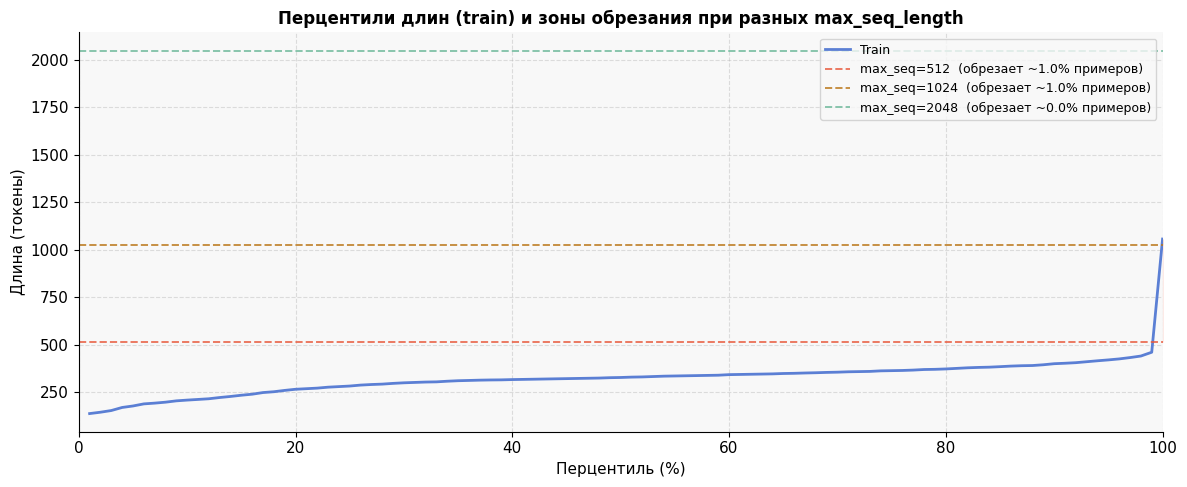

✅ График сохранён: plots/plot3_percentiles.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

percentiles = np.arange(1, 101)
perc_values = [np.percentile(train_arr, p) for p in percentiles]

ax.plot(
    percentiles, perc_values, color="#5B7FD4", linewidth=2.0, label="Train"
)

# Закрашиваем зону потерь для каждого варианта max_seq_length
seq_options = [512, 1024, 2048]
opt_colors = ["#E8593C", "#BA7517", "#6DB89A"]
opt_alpha = [0.12, 0.10, 0.08]

for seq_len, color, alpha in zip(seq_options, opt_colors, opt_alpha):
    cutoff_pct = np.searchsorted(perc_values, seq_len)
    pct_lost = 100 - cutoff_pct
    ax.axhline(
        seq_len,
        color=color,
        linewidth=1.4,
        linestyle="--",
        alpha=0.8,
        label=f"max_seq={seq_len}  (обрезает ~{pct_lost:.1f}% примеров)",
    )
    ax.fill_between(
        percentiles,
        perc_values,
        seq_len,
        where=[v > seq_len for v in perc_values],
        color=color,
        alpha=alpha,
    )

ax.set_title(
    "Перцентили длин (train) и зоны обрезания при разных max_seq_length",
    fontsize=12,
    fontweight="bold",
)
ax.set_xlabel("Перцентиль (%)")
ax.set_ylabel("Длина (токены)")
ax.legend(fontsize=9)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig(
    "/home/danil-pc/fine-tuning_project/plots/plot3_percentiles.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()
print("График сохранён: plots/plot3_percentiles.png")

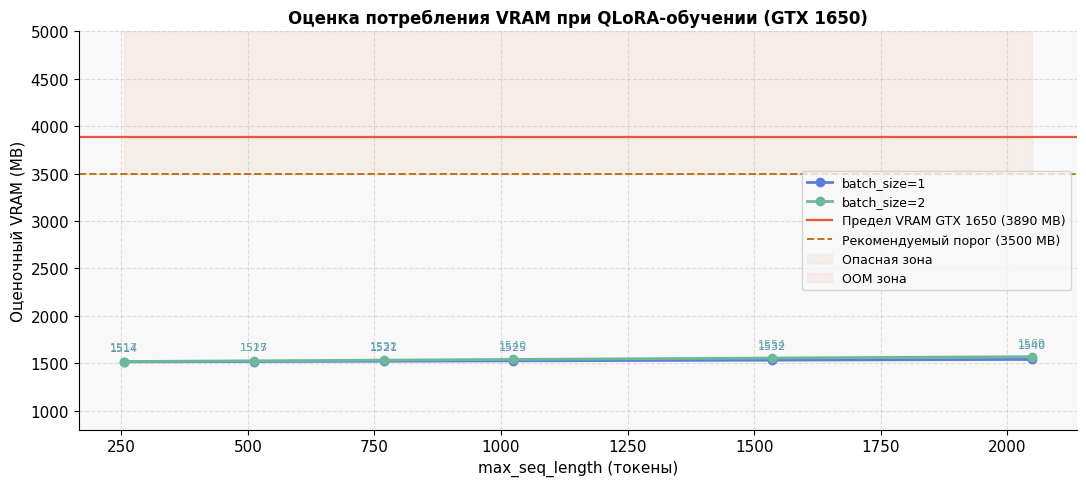

✅ График сохранён: plots/plot4_vram.png


In [ ]:
seq_lengths = [256, 512, 768, 1024, 1536, 2048]
batch_sizes = [1, 2]
vram_limit = 3890  # GTX 1650 max VRAM в MB
vram_safe = 3500  # Рекомендуемый порог с запасом

fig, ax = plt.subplots(figsize=(11, 5))

line_colors = {"1": "#5B7FD4", "2": "#6DB89A"}

for bs in batch_sizes:
    vrams = [estimate_vram_mb(sl, bs) for sl in seq_lengths]
    ax.plot(
        seq_lengths,
        vrams,
        marker="o",
        linewidth=2.0,
        color=line_colors[str(bs)],
        label=f"batch_size={bs}",
    )
    # Подписи значений над точками
    for sl, v in zip(seq_lengths, vrams):
        ax.annotate(
            f"{v:.0f}",
            xy=(sl, v),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color=line_colors[str(bs)],
        )

# Линии ограничений
ax.axhline(
    vram_limit,
    color="#E8593C",
    linewidth=1.6,
    linestyle="-",
    label=f"Предел VRAM GTX 1650 ({vram_limit} MB)",
)
ax.axhline(
    vram_safe,
    color="#BA7517",
    linewidth=1.4,
    linestyle="--",
    label=f"Рекомендуемый порог ({vram_safe} MB)",
)

# Зона опасности
ax.fill_between(
    seq_lengths,
    [vram_safe] * len(seq_lengths),
    [vram_limit] * len(seq_lengths),
    color="#BA7517",
    alpha=0.07,
    label="Опасная зона",
)
ax.fill_between(
    seq_lengths,
    [vram_limit] * len(seq_lengths),
    [5000] * len(seq_lengths),
    color="#E8593C",
    alpha=0.07,
    label="OOM зона",
)

ax.set_title(
    "Оценка потребления VRAM при QLoRA-обучении (GTX 1650)",
    fontsize=12,
    fontweight="bold",
)
ax.set_xlabel("max_seq_length (токены)")
ax.set_ylabel("Оценочный VRAM (MB)")
ax.set_ylim(800, 5000)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    "/home/danil-pc/fine-tuning_project/plots/plot4_vram.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()
print(" График сохранён: plots/plot4_vram.png")

In [ ]:
p95_train = int(np.percentile(train_arr, 95))
p99_train = int(np.percentile(train_arr, 99))
rec_seq = round_up_power2(p95_train)

vram_b2 = estimate_vram_mb(rec_seq, batch=2)
vram_b1 = estimate_vram_mb(rec_seq, batch=1)

print("=" * 56)
print("  ИТОГОВЫЕ РЕКОМЕНДАЦИИ ПО КОНФИГУРАЦИИ")
print("=" * 56)
print("\n  Данные:")
print(f"    Train p95: {p95_train} токенов")
print(f"    Train p99: {p99_train} токенов")
print(f"    Train max: {train_arr.max()} токенов")

print(f"\n  Рекомендуемый max_seq_length: {rec_seq}")
print(f"    (p95 = {p95_train} → ближайшая степень двойки)")

print(f"\n  Оценка VRAM при max_seq_length={rec_seq}:")
status_b2 = (
    " OK" if vram_b2 < 3500 else ("  На грани" if vram_b2 < 3890 else "❌ OOM")
)
status_b1 = (
    " OK" if vram_b1 < 3500 else ("  На грани" if vram_b1 < 3890 else "❌ OOM")
)
print(f"    batch_size=2: ~{vram_b2:.0f} MB  {status_b2}")
print(f"    batch_size=1: ~{vram_b1:.0f} MB  {status_b1}")

print("\n  Рекомендация по training_config.yaml:")
final_batch = 2 if vram_b2 < 3500 else 1
final_accum = 8 // final_batch  # Держим effective batch = 8
print(f"    max_seq_length: {rec_seq}")
print(f"    per_device_train_batch_size: {final_batch}")
print(
    f"    gradient_accumulation_steps: {final_accum}  # effective batch = {final_batch * final_accum}"
)
print("=" * 56)

  ИТОГОВЫЕ РЕКОМЕНДАЦИИ ПО КОНФИГУРАЦИИ

  Данные:
    Train p95: 419 токенов
    Train p99: 459 токенов
    Train max: 1056 токенов

  Рекомендуемый max_seq_length: 512
    (p95 = 419 → ближайшая степень двойки)

  Оценка VRAM при max_seq_length=512:
    batch_size=2: ~1525 MB  ✅ OK
    batch_size=1: ~1517 MB  ✅ OK

  Рекомендация по training_config.yaml:
    max_seq_length: 512
    per_device_train_batch_size: 2
    gradient_accumulation_steps: 4  # effective batch = 8


In [ ]:
THRESHOLD = 512  # Порог для исследования

long_examples = []

with open(TRAIN_FILE, encoding="utf-8") as f:
    for idx, line in enumerate(f):
        sample = json.loads(line.strip())
        formatted = format_sample(sample)
        n_tokens = len(tokenizer.encode(formatted, add_special_tokens=False))

        if n_tokens > THRESHOLD:
            long_examples.append(
                {
                    "idx": idx,
                    "n_tokens": n_tokens,
                    "source": sample.get("source", "unknown"),
                    "messages": sample["messages"],
                    "formatted": formatted,
                }
            )

# Сортируем по убыванию длины
long_examples.sort(key=lambda x: x["n_tokens"], reverse=True)

print(
    f"Примеров длиннее {THRESHOLD} токенов: {len(long_examples)} "
    f"из {len(train_lens)} ({len(long_examples) / len(train_lens) * 100:.1f}%)\n"
)

# Разбивка по источникам
from collections import Counter

src_counts = Counter(e["source"] for e in long_examples)
for src, cnt in src_counts.most_common():
    print(f"  {src:20}: {cnt} примеров")

print("\nТоп-10 самых длинных:")
print(f"  {'#':>4}  {'idx':>5}  {'токены':>7}  {'источник'}")
print(f"  {'─' * 42}")
for i, ex in enumerate(long_examples[:10]):
    print(f"  {i + 1:>4}  {ex['idx']:>5}  {ex['n_tokens']:>7}  {ex['source']}")

Примеров длиннее 512 токенов: 3 из 1105 (0.3%)

  unknown             : 3 примеров

Топ-10 самых длинных:
     #    idx   токены  источник
  ──────────────────────────────────────────
     1    352     1056  unknown
     2    478      550  unknown
     3    852      520  unknown


In [ ]:
i = 1

ex = long_examples[i]
msgs = ex["messages"]

print(f"{'=' * 60}")
print(f"Пример #{i + 1}  |  Индекс в файле: {ex['idx']}")
print(f"Длина: {ex['n_tokens']} токенов  |  Источник: {ex['source']}")
print(f"{'=' * 60}\n")

for msg in msgs:
    role = msg["role"].upper()
    content = msg["content"]
    tokens_in_msg = len(tokenizer.encode(content, add_special_tokens=False))
    print(f"[{role}]  ({tokens_in_msg} токенов)")
    print(f"{content}")
    print(f"{'─' * 60}")

Пример #2  |  Индекс в файле: 478
Длина: 550 токенов  |  Источник: unknown

[SYSTEM]  (17 токенов)
You are a helpful coding assistant. Provide clear, working Python code with brief explanations.
────────────────────────────────────────────────────────────
[USER]  (255 токенов)
Create a program sudoku solver in Python.

[Sudoku board]

[5, 3, 0, 0, 7, 0, 0, 0, 0]
[6, 0, 0, 1, 9, 5, 0, 0, 0]
[0, 9, 8, 0, 0, 0, 0, 6, 0]
[8, 0, 0, 0, 6, 0, 0, 0, 3]
[4, 0, 0, 8, 0, 3, 0, 0, 1]
[7, 0, 0, 0, 2, 0, 0, 0, 6]
[0, 6, 0, 0, 0, 0, 2, 8, 0]
[0, 0, 0, 4, 1, 9, 0, 0, 5]
[0, 0, 0, 0, 8, 0, 0, 7, 9]
────────────────────────────────────────────────────────────
[ASSISTANT]  (263 токенов)
def solve(bo):
    find = find_empty(bo)
    if not find:
        return True
    else:
        row, col = find

    for i in range(1,10):
        if valid(bo, i, (row, col)):
            bo[row][col] = i

            if solve(bo):
                return True

            bo[row][col] = 0

    return False


def valid(bo,

In [ ]:
q_tokens, a_tokens = [], []

with open(TRAIN_FILE, encoding="utf-8") as f:
    for line in f:
        sample = json.loads(line.strip())
        for msg in sample["messages"]:
            n = len(tokenizer.encode(msg["content"], add_special_tokens=False))
            if msg["role"] == "user":
                q_tokens.append(n)
            elif msg["role"] == "assistant":
                a_tokens.append(n)

q_arr = np.array(q_tokens)
a_arr = np.array(a_tokens)

print("Вопросы (user):")
print(
    f"  avg={q_arr.mean():.0f}  median={np.median(q_arr):.0f}  "
    f"p95={np.percentile(q_arr, 95):.0f}  max={q_arr.max()}"
)

print("\nОтветы (assistant):")
print(
    f"  avg={a_arr.mean():.0f}  median={np.median(a_arr):.0f}  "
    f"p95={np.percentile(a_arr, 95):.0f}  max={a_arr.max()}"
)

print("\nВывод: если длинные — это в основном ответы, то обрезка")
print("будет срезать именно полезный контент модели.")

Вопросы (user):
  avg=32  median=29  p95=56  max=386

Ответы (assistant):
  avg=229  median=233  p95=318  max=638

Вывод: если длинные — это в основном ответы, то обрезка
будет срезать именно полезный контент модели.


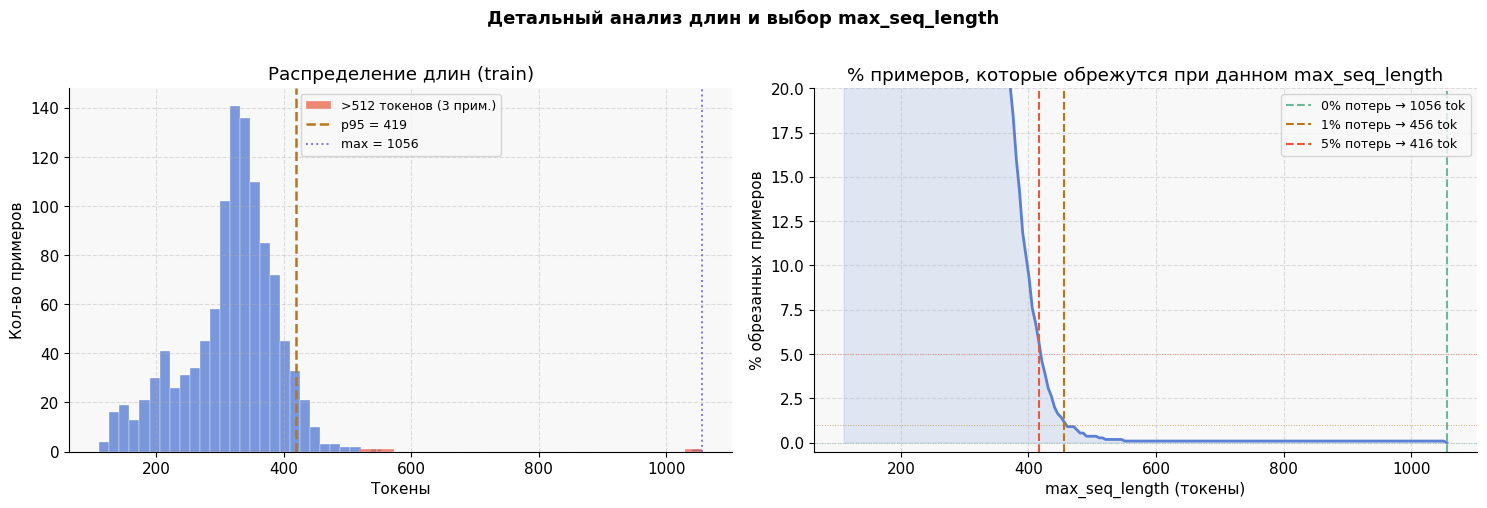

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    "Детальный анализ длин и выбор max_seq_length",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)

# ── Левый: гистограмма с зумом на хвост ──────────────────────────────────────
ax = axes[0]
ax.hist(
    train_arr,
    bins=60,
    color="#5B7FD4",
    alpha=0.8,
    edgecolor="white",
    linewidth=0.3,
)

# Подсвечиваем хвост (> 512)
tail = train_arr[train_arr > THRESHOLD]
if len(tail):
    ax.hist(
        tail,
        bins=20,
        color="#E8593C",
        alpha=0.7,
        edgecolor="white",
        linewidth=0.3,
        label=f">{THRESHOLD} токенов ({len(tail)} прим.)",
    )

ax.axvline(
    np.percentile(train_arr, 95),
    color="#BA7517",
    linewidth=1.8,
    linestyle="--",
    label=f"p95 = {int(np.percentile(train_arr, 95))}",
)
ax.axvline(
    train_arr.max(),
    color="#7F77DD",
    linewidth=1.4,
    linestyle=":",
    label=f"max = {train_arr.max()}",
)

ax.set_title("Распределение длин (train)")
ax.set_xlabel("Токены")
ax.set_ylabel("Кол-во примеров")
ax.legend(fontsize=9)

# ── Правый: сколько % примеров обрезается при разных порогах ─────────────────
ax2 = axes[1]

# Перебираем все возможные пороги от min до max
thresholds = np.arange(train_arr.min(), train_arr.max() + 1, 5)
pct_cut = [(train_arr > t).sum() / len(train_arr) * 100 for t in thresholds]

ax2.plot(thresholds, pct_cut, color="#5B7FD4", linewidth=2.0)
ax2.fill_between(thresholds, pct_cut, alpha=0.15, color="#5B7FD4")

# Отмечаем ключевые точки: 0%, 1%, 5%
for target_pct, color, label in [
    (0, "#6DB89A", "0% потерь"),
    (1, "#BA7517", "1% потерь"),
    (5, "#E8593C", "5% потерь"),
]:
    # Ищем порог, при котором обрезается ровно target_pct%
    idx = np.searchsorted(pct_cut[::-1], target_pct)
    t_val = thresholds[::-1][idx] if idx < len(thresholds) else thresholds[-1]
    ax2.axvline(
        t_val,
        color=color,
        linewidth=1.5,
        linestyle="--",
        label=f"{label} → {t_val:.0f} tok",
    )
    ax2.axhline(
        target_pct, color=color, linewidth=0.7, linestyle=":", alpha=0.6
    )

ax2.set_title("% примеров, которые обрежутся при данном max_seq_length")
ax2.set_xlabel("max_seq_length (токены)")
ax2.set_ylabel("% обрезанных примеров")
ax2.set_ylim(-0.5, min(20, max(pct_cut) + 1))
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    "/home/danil-pc/fine-tuning_project/plots/plot5_cutoff_analysis.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [ ]:
print("=" * 56)
print("  ТОЧНЫЕ ПОРОГИ (без округления до степени двойки)")
print("=" * 56)

for target_pct in [0.0, 0.5, 1.0, 2.0, 5.0]:
    # Минимальный max_seq_len при котором обрезается <= target_pct%
    threshold_val = int(np.percentile(train_arr, 100 - target_pct))
    cut_count = (train_arr > threshold_val).sum()
    vram_b2 = estimate_vram_mb(threshold_val, batch=2)
    vram_b1 = estimate_vram_mb(threshold_val, batch=1)
    status = "✅" if vram_b2 < 3500 else ("⚠️" if vram_b2 < 3890 else "❌")

    print(
        f"\n  Потери ≤ {target_pct:.1f}%  →  max_seq_length = {threshold_val}"
    )
    print(f"    Обрежется примеров: {cut_count}")
    print(f"    VRAM batch=2: ~{vram_b2:.0f} MB {status}")
    print(f"    VRAM batch=1: ~{vram_b1:.0f} MB")

print(f"\n{'─' * 56}")
print(f"  Для справки: train_arr.max() = {train_arr.max()} токенов")
print(f"  При max_seq_length={train_arr.max()} → 0 потерь,")
vram_max = estimate_vram_mb(train_arr.max(), 2)
status = "✅" if vram_max < 3500 else ("⚠️" if vram_max < 3890 else "❌")
print(f"  VRAM batch=2: ~{vram_max:.0f} MB {status}")
print("=" * 56)

  ТОЧНЫЕ ПОРОГИ (без округления до степени двойки)

  Потери ≤ 0.0%  →  max_seq_length = 1056
    Обрежется примеров: 0
    VRAM batch=2: ~1540 MB ✅
    VRAM batch=1: ~1525 MB

  Потери ≤ 0.5%  →  max_seq_length = 484
    Обрежется примеров: 6
    VRAM batch=2: ~1524 MB ✅
    VRAM batch=1: ~1517 MB

  Потери ≤ 1.0%  →  max_seq_length = 459
    Обрежется примеров: 12
    VRAM batch=2: ~1523 MB ✅
    VRAM batch=1: ~1517 MB

  Потери ≤ 2.0%  →  max_seq_length = 440
    Обрежется примеров: 22
    VRAM batch=2: ~1523 MB ✅
    VRAM batch=1: ~1516 MB

  Потери ≤ 5.0%  →  max_seq_length = 419
    Обрежется примеров: 56
    VRAM batch=2: ~1522 MB ✅
    VRAM batch=1: ~1516 MB

────────────────────────────────────────────────────────
  Для справки: train_arr.max() = 1056 токенов
  При max_seq_length=1056 → 0 потерь,
  VRAM batch=2: ~1540 MB ✅


Думаю, что нужно взять `max_seq_len` = 550, потому что это второй по длине элемент выборки, а то что первый обрежется - ничего страшного, его можно отпустить, слишком много ресурсов нужно потратить только ради того, чтобы охватить один пример 

Мне предлают просто отфилтровать самый длинный пример, но я пока этого не делал, дальше решу этот момент